In [ ]:
%load_ext autoreload
%autoreload 2


import pandas as pd
import torch
from torch.utils.data import DataLoader
from dataset import CustomDataset
from dnn_model import DnnWOTransformer
import torch.nn as nn
from sklearn.metrics import ndcg_score
import scipy.stats as stats
import numpy as np
from datetime import datetime
import os
from scipy import stats
import numpy as np
from sklearn.metrics import ndcg_score, root_mean_squared_error
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
# ucitavanje podataka i popunjavanje nan vrednosti
csv_path = "tables\\zaModel.csv" 
df = pd.read_csv(csv_path)
df = df.fillna(-1)

In [53]:
#da se izbace prazna mesta iz imena kolona
df.columns = df.columns.str.strip()

#kategorijske i numericke kolone
categorical_cols = ['constructor', 'driverId', 'race_name',
                                'circuit']

numerical_cols = ['season', 'round', 'position_quali', 'grid',
                  'number_of_laps', 'number_of_corners', 'lap_length', 
                  'AirTemp', 'Humidity', 'Pressure', 'TrackTemp', 
                  'WindSpeed', 'rain_bin', 'wind_direction', 
                  'last_year_time', 'avg_position_last5', 
                  'num_dnfs_last5', 'avg_gained_lost_last5',
                  'avg_pos_last5', 'avg_pit_duration_last5',
                  'avg_pit_duration_prev_race','avg_pit_duration_prev_driver_race', 
                  'avg_overtakes_prev_season_per_circuit', 'best_qual_time_ms']

In [54]:
# kodiranje u int da bi dnn mogao da radi sa podacima
target_col = 'position_race'
for col in categorical_cols:
    if df[col].dtype == 'object': 
        df[col], uniques = pd.factorize(df[col])
        print(f"Kolona '{col}' kodirana u int. Broj unikatnih vrednosti: {len(uniques)}")

Kolona 'constructor' kodirana u int. Broj unikatnih vrednosti: 16
Kolona 'driverId' kodirana u int. Broj unikatnih vrednosti: 40
Kolona 'race_name' kodirana u int. Broj unikatnih vrednosti: 36
Kolona 'circuit' kodirana u int. Broj unikatnih vrednosti: 31


In [55]:
# invertovanje targeta tako da veci broj ozcava goru poziciju
df[target_col] = df[target_col].apply(lambda x: -x)

In [56]:
batch_size = 4
embedding_dim = 8
num_numerical = len(numerical_cols)
hidden_dim = 512
dropout = 0.1
lr = 0.001

In [57]:
dataset = CustomDataset(df, target_col, numerical_cols, categorical_cols)
loader_test = DataLoader(dataset, batch_size, shuffle=False)

In [58]:
embeddings_dict = {
    col: dataset.num_of_cat_features[col]
    for col in categorical_cols
}

In [ ]:
#loss funkcija
class ListNetLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, pred_scores, target_ranks):
        # racunanje verovatnoce raspodele
        true_prob = torch.softmax(target_ranks, dim=1)
        pred_log_prob = torch.log_softmax(pred_scores, dim=1)

        # Cross entropy izmedju distrbucija
        loss = -torch.sum(true_prob * pred_log_prob, dim=1).mean()
        return loss


In [60]:
df = df.sort_values(by=["season", "round"]).reset_index(drop=True)

# uzima sve trke, bez ponavljanja
unique_races = df[["season", "round"]].drop_duplicates().reset_index(drop=True)
num_races = len(unique_races)

# velicina train, validacionog i test seta
train_size = int(num_races * 0.65)
val_size = int(num_races * 0.1)+2
test_size = num_races - train_size - val_size 

# Podela
train_races = unique_races.iloc[:train_size]
val_races = unique_races.iloc[train_size:train_size + val_size]
test_races = unique_races.iloc[train_size + val_size:]

# sve kolone za svaki od setova
train_df = df.merge(train_races, on=["season", "round"])
val_df = df.merge(val_races, on=["season", "round"])
test_df = df.merge(test_races, on=["season", "round"])

In [61]:
print(val_size, test_size, train_size)

16 36 96


In [62]:
# ucitavanje dataseta i data loader
dataset_train = CustomDataset(train_df, target_col, numerical_cols, categorical_cols)
dataset_val = CustomDataset(val_df, target_col, numerical_cols, categorical_cols)
dataset_test =  CustomDataset(test_df, target_col, numerical_cols, categorical_cols)


loader_test = DataLoader(dataset_test, batch_size, shuffle=False)
loader_val = DataLoader(dataset_val, batch_size, shuffle=False)
loader_train = DataLoader(dataset_train, batch_size, shuffle=False)

In [ ]:
#folder u koji ce da se cuva model
timern = datetime.now().strftime('%d-%m-%Y_%H-%M-%S')
path = f'models_camp\\dnn\\{timern}'
os.mkdir(path)

In [64]:
path

'models_camp\\dnn\\03-07-2025_10-31-19'

In [65]:
# inicijalizacija moddela
model = DnnWOTransformer(embeddings_dict, num_numerical, embedding_dim, hidden_dim=hidden_dim, dropout_p=dropout)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

#loss
criterion = ListNetLoss()  

#optimizer
optimizer = torch.optim.SGD(model.parameters(), lr, weight_decay=0.0001)

val_loss_list = []
ndcg_train = []
loss_list_train = []
loss_list_train = []
ndcg_values_valid = []
ndcg_values_valid_one_epoch = []


In [66]:
# broj epoha
num_epochs = 150 + 1

In [67]:
# treniranje
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    ndcg_values = []

    for batch_idx, (cat_features, num_tensor, target, drivers_num, position_quali) in enumerate(loader_train):
        #prebacivanje na cuda-u ako postoji
        cat_features = {k: v.to(device) for k, v in cat_features.items()}
        num_tensor = num_tensor.to(device)
        target = target.to(device)

        # predvidjanje modela, loss, optimizer
        optimizer.zero_grad()
        output = model(cat_features, num_tensor).squeeze(-1)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        scores_np = output.cpu().detach().numpy()
        true_rank_np = target.cpu().numpy()
        # racunanje metrike
        for i in range(true_rank_np.shape[0]):
            ndcg = ndcg_score([-true_rank_np[i]], [scores_np[i]], k=10)
            ndcg_values.append(ndcg)

    avg_loss = running_loss / len(loader_train)
    avg_ndcg = sum(ndcg_values) / len(ndcg_values)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, NDCG: {avg_ndcg:.4f}, lr: {lr}")

    model.eval()
    val_loss = 0.0
    ndcg_values_valid_one_epoch = []

    #validacija
    with torch.no_grad():
        for batch_idx, (cat_features, num_tensor, target, drivers_num, position_quali) in enumerate(loader_val):
            cat_features = {k: v.to(device) for k, v in cat_features.items()}
            num_tensor = num_tensor.to(device)
            target = target.to(device)

            output = model(cat_features, num_tensor).squeeze(-1)
            loss = criterion(output, target)
            val_loss += loss.item()

            scores_np = output.cpu().numpy()
            true_rank_np = target.cpu().numpy()
            for i in range(true_rank_np.shape[0]):
                ndcg = ndcg_score([-true_rank_np[i]], [scores_np[i]], k=10)
                ndcg_values_valid_one_epoch.append(ndcg)

    avg_val_loss = val_loss / len(loader_val)
    avg_ndcg_valid = sum(ndcg_values_valid_one_epoch) / len(ndcg_values_valid_one_epoch)

    print(f"Validacioni loss: {avg_val_loss:.4f}")
    print(f"Validacioni NDCG: {avg_ndcg_valid:.4f}")

    #cuvanje vrednosti za plotovanje
    loss_list_train.append(avg_loss)
    ndcg_train.append(avg_ndcg)
    val_loss_list.append(avg_val_loss)
    ndcg_values_valid.append(avg_ndcg_valid)

    # cuvanje modela na svakih 5 epoha
    if epoch % 5 == 0:
        torch.save(model.state_dict(), os.path.join(path, f'{epoch}.pth'))
        print(f'Saved to models {epoch}.pth')


Epoch 1/151, Loss: 2.9954, NDCG: 0.6107, lr: 0.001
Validacioni loss: 2.9930
Validacioni NDCG: 0.6089
Saved to models 0.pth
Epoch 2/151, Loss: 2.9936, NDCG: 0.6016, lr: 0.001
Validacioni loss: 2.9908
Validacioni NDCG: 0.6041
Epoch 3/151, Loss: 2.9926, NDCG: 0.5977, lr: 0.001
Validacioni loss: 2.9884
Validacioni NDCG: 0.6212
Epoch 4/151, Loss: 2.9896, NDCG: 0.5790, lr: 0.001
Validacioni loss: 2.9855
Validacioni NDCG: 0.6307
Epoch 5/151, Loss: 2.9892, NDCG: 0.5770, lr: 0.001
Validacioni loss: 2.9833
Validacioni NDCG: 0.6244
Epoch 6/151, Loss: 2.9864, NDCG: 0.5824, lr: 0.001
Validacioni loss: 2.9806
Validacioni NDCG: 0.6206
Saved to models 5.pth
Epoch 7/151, Loss: 2.9838, NDCG: 0.5718, lr: 0.001
Validacioni loss: 2.9784
Validacioni NDCG: 0.6207
Epoch 8/151, Loss: 2.9827, NDCG: 0.5805, lr: 0.001
Validacioni loss: 2.9760
Validacioni NDCG: 0.6215
Epoch 9/151, Loss: 2.9816, NDCG: 0.5896, lr: 0.001
Validacioni loss: 2.9737
Validacioni NDCG: 0.6266
Epoch 10/151, Loss: 2.9802, NDCG: 0.5816, lr: 0

In [68]:
len(dataset_train)

96

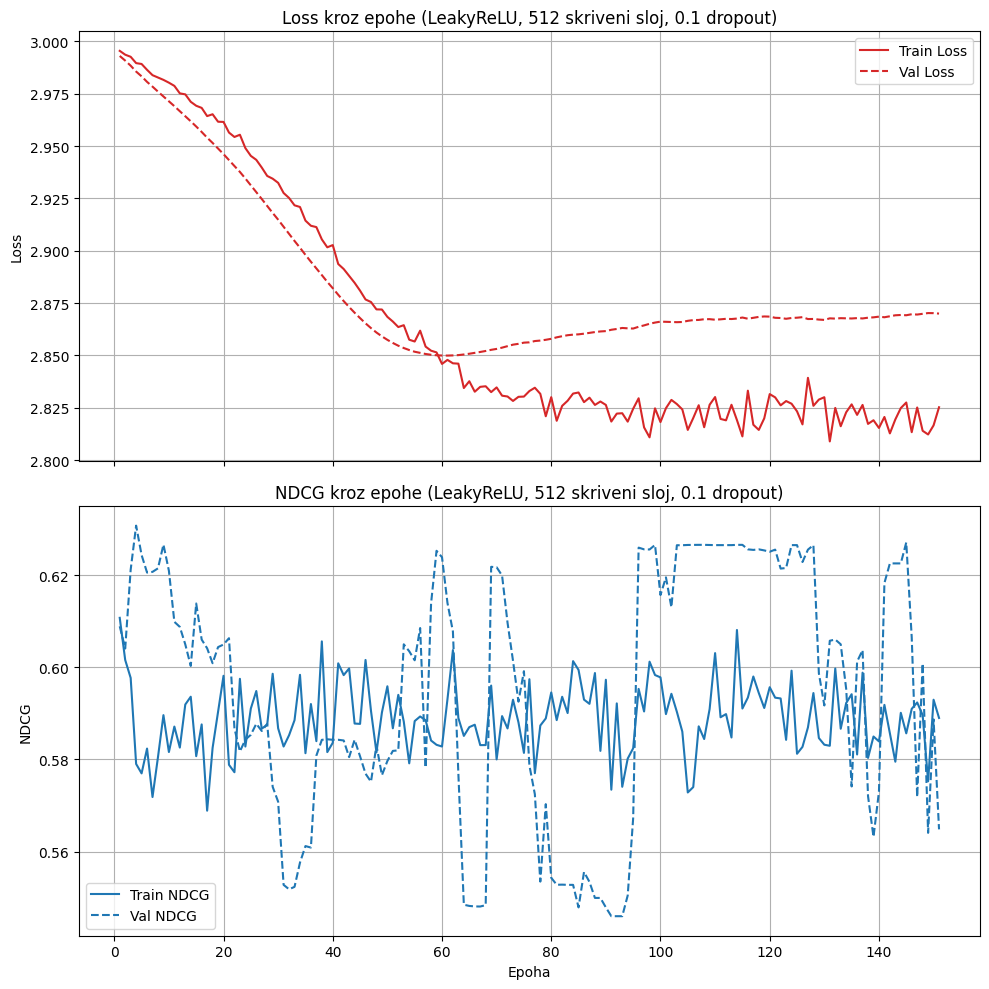

In [ ]:
epochs = list(range(1, len(loss_list_train) + 1))

fig, axs = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Prvi subplot – Loss
axs[0].plot(epochs, loss_list_train, label='Train Loss', color='tab:red', linestyle='-')
axs[0].plot(epochs, val_loss_list, label='Val Loss', color='tab:red', linestyle='--')
axs[0].set_ylabel('Loss')
axs[0].set_title(f'Loss kroz epohe (LeakyReLU, {hidden_dim} skriveni sloj, {dropout} dropout)')
axs[0].legend()
axs[0].grid(True)

# Drugi subplot – NDCG
axs[1].plot(epochs, ndcg_train, label='Train NDCG', color='tab:blue', linestyle='-')
axs[1].plot(epochs, ndcg_values_valid, label='Val NDCG', color='tab:blue', linestyle='--')
axs[1].set_xlabel('Epoha')
axs[1].set_ylabel('NDCG')
axs[1].set_title(f'NDCG kroz epohe (LeakyReLU, {hidden_dim} skriveni sloj, {dropout} dropout)')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


In [70]:
fig.savefig(os.path.join(path, 'metrike.jpg'))

In [71]:
from scipy import stats
import numpy as np
from sklearn.metrics import ndcg_score, root_mean_squared_error

# Pomerimo sve na CPU i u NumPy
try:
    true_rank_np = target.cpu().numpy()  
    scores_np = scores_np  
except:
    true_rank_np = target
    scores_np = scores_np

# Invertujemo rang
true_relevance = -true_rank_np

ndcg_values = []
tau_list = []
spearman_list = []
rmse_list = []

for i in range(true_relevance.shape[0]):
    # NDCG@10
    ndcg = ndcg_score([true_relevance[i]], [scores_np[i]], k=10)
    ndcg_values.append(ndcg)

    # Kendall's Tau i Spearman
    tau, _ = stats.kendalltau(true_rank_np[i], -scores_np[i])
    spearman, _ = stats.spearmanr(true_rank_np[i], -scores_np[i])
    tau_list.append(tau)
    spearman_list.append(spearman)

    # RMSE
    ranks_pred = pd.DataFrame(-scores_np[i]).rank(ascending=True, method='min').values.flatten()
    rmse = root_mean_squared_error(true_rank_np[i], ranks_pred)
    rmse_list.append(rmse)

# Prosečne metrike
avg_ndcg = np.mean(ndcg_values)
avg_tau = np.nanmean(tau_list)
avg_spearman = np.nanmean(spearman_list)
avg_rmse = np.mean(rmse_list)

print(f"Average NDCG@10: {avg_ndcg:.4f}")
print(f"Average Kendall's Tau: {avg_tau:.4f}")
print(f"Average Spearman: {avg_spearman:.4f}")
print(f"Average RMSE: {avg_rmse:.4f}")


Average NDCG@10: 0.6071
Average Kendall's Tau: -0.0777
Average Spearman: -0.1416
Average RMSE: 22.7180


In [72]:
race_index = 13  #indeks trke za koju se pisu rezultati

with torch.no_grad():
    for batch_idx, (cat_features, num_tensor, target, drivers_num, position_quali) in enumerate(loader_test):
        if race_index // batch_size == batch_idx:
            sample_idx = race_index % batch_size  # indeks unutar batcha

            cat_features = {k: v.to(device) for k, v in cat_features.items()}
            num_tensor = num_tensor.to(device)
            target = target.to(device)

            output = model(cat_features, num_tensor).squeeze(-1)

            # Samo jedna trka iz batcha
            scores = output[sample_idx].cpu().numpy()
            true_ranks = target[sample_idx].cpu().numpy()
            quali_pos = position_quali[sample_idx].numpy()
            driver_ids = drivers_num[sample_idx].numpy()

            # Sortiranje po predikcijama
            pred_order = scores.argsort()

            print(f"Poređenje za trku #{race_index}:\n")
            print(f"{'Poz':<5}{'Vozač':<10}{'Stvarna':<10}{'Predviđena':<12}{'Kvalifikacije':<15}")
            for pos, idx in enumerate(pred_order):
                print(f"{pos+1:<5}{driver_ids[idx]:<10}{-true_ranks[idx]:<10}{pos+1:<12}{quali_pos[idx]:<15}")
            break


Poređenje za trku #13:

Poz  Vozač     Stvarna   Predviđena  Kvalifikacije  
1    24        11.0      1           17             
2    31        17.0      2           19             
3    2         20.0      3           18             
4    27        16.0      4           10             
5    20        12.0      5           15             
6    3         13.0      6           14             
7    81        8.0       7           8              
8    4         6.0       8           7              
9    16        4.0       9           2              
10   33        1.0       10          1              
11   11        2.0       11          5              
12   14        9.0       12          6              
13   55        3.0       13          4              
14   44        7.0       14          9              
15   18        10.0      15          12             
16   63        5.0       16          3              
17   77        19.0      17          16             
18   10        18.0   